In [1]:
import yfinance as yf

stk_data = yf.download("ITC.NS",
                       start="2021-06-01",
                       end="2026-02-22")

# Remove MultiIndex if present
if isinstance(stk_data.columns, tuple) or hasattr(stk_data.columns, 'levels'):
    stk_data.columns = stk_data.columns.get_level_values(0)

stk_data = stk_data[['Open', 'High', 'Low', 'Close', 'Volume']]

print(stk_data.head())

[*********************100%***********************]  1 of 1 completed

Price             Open        High         Low       Close     Volume
Date                                                                 
2021-06-01  171.372432  172.472991  168.424513  169.210617   40247686
2021-06-02  165.476615  167.009534  163.982998  164.297440  100377464
2021-06-03  165.673145  165.673145  164.061609  164.336761   48454441
2021-06-04  164.690473  164.847693  163.511310  164.100891   31286264
2021-06-07  165.397985  166.970206  165.240764  166.223404   32643869


In [2]:
column="Close"

In [3]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (1172, 1)


In [4]:
training_size = round(len(data1 ) * 0.95)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

1113
X_train length: (1113, 1)
X_test length: (59, 1)
y_train length: (1113, 1)
y_test length: (59, 1)


In [5]:
import warnings
warnings.filterwarnings("ignore")

In [39]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Define parameter ranges
p_values = range(0, 4)
d_values = range(0, 2)
q_values = range(0, 4)
trends = ['n', 'c', 't', 'ct']

results = []

for p in p_values:
    for d in d_values:
        for q in q_values:
            for trend in trends:
                try:
                    model = ARIMA(X_train, order=(p,d,q), trend=trend)
                    model_fit = model.fit()

                    y_pred = model_fit.predict(start=len(X_train),
                                               end=len(X_train)+len(y_test)-1)

                    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

                    results.append({
                        "Order": (p,d,q),
                        "Trend": trend,
                        "AIC": model_fit.aic,
                        "BIC": model_fit.bic,
                        "RMSE": rmse
                    })

                except:
                    continue

results_df = pd.DataFrame(results)

# Sort by AIC
best_model = results_df.sort_values("AIC").iloc[0]

print("Best Model Based on AIC")
print(best_model)

results_df.sort_values("AIC").head()

C:\Users\mojayara\time_series_analysis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\mojayara\time_series_analysis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\mojayara\time_series_analysis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\mojayara\time_series_analysis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\mojayara\time_series_analysis\Lib\s

Best Model Based on AIC
Order      (1, 0, 0)
Trend              t
AIC     -6571.339978
BIC     -6556.295535
RMSE        0.212585
Name: 26, dtype: object


,Order,Trend,AIC,BIC,RMSE
26,"(1, 0, 0)",t,-6571.339978,-6556.295535,0.212585
17,"(0, 1, 0)",t,-6570.824071,-6560.796240,0.202844
30,"(1, 0, 1)",t,-6570.806018,-6550.746761,0.210141
50,"(2, 0, 0)",t,-6570.787270,-6550.728012,0.210209
19,"(0, 1, 1)",t,-6570.519225,-6555.477479,0.202754


In [41]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score
from stockFunctions import rmsemape

td = "c"

# Build ARIMA model
model = ARIMA(X_train, order=(0, 0, 30), trend=td)
model_fit = model.fit()

# Correct prediction range
y_pred = model_fit.predict(start=len(X_train),
                           end=len(X_train) + len(y_test) - 1)

# Safe RMSE calculation (compatible with all sklearn versions)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R2 score
r2 = r2_score(y_test, y_pred)

print(f"Trend={td}")
print("RMSE:", rmse)
print("R2:", r2)

rmsemape(y_test, y_pred)

print("************")

C:\Users\mojayara\time_series_analysis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Trend=c
RMSE: 0.07349632574605856
R2: 0.5741020757606868
RMSE-Testset: 0.07349632574605856
MAPE-Testset: 8.707281072400473
************


In [42]:
# #i=1
# td="c"
# model = ARIMA(X_train, order=(0,0,30),trend=td)
# model_fit = model.fit()
# # make prediction
# y_pred= model_fit.predict(len(X_train), len(data1)-1)
# #print(y_pred)
# from sklearn.metrics import r2_score
# mse=mean_squared_error(y_test,y_pred)
# from stockFunctions import rmsemape
# print("Trend={}".format(td))
# rmsemape(y_test,y_pred)
# print("************")

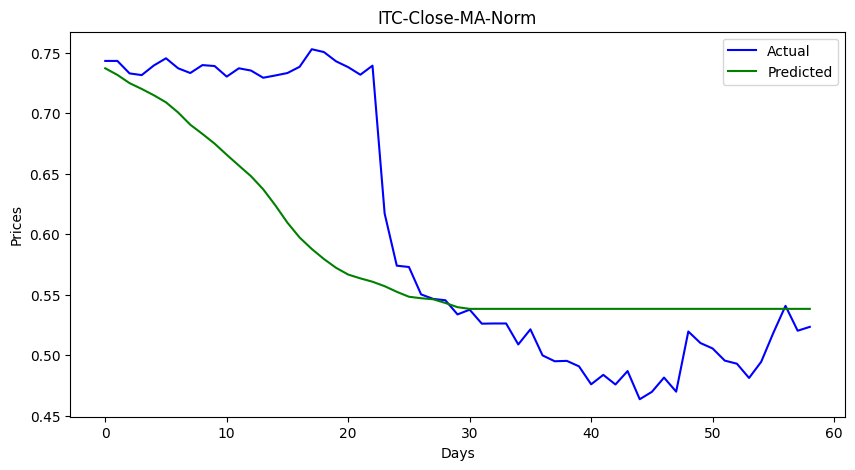

In [43]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","ITC-Close-MA-Norm","Days","Prices")

In [36]:
len(data1)

1172

In [44]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [45]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

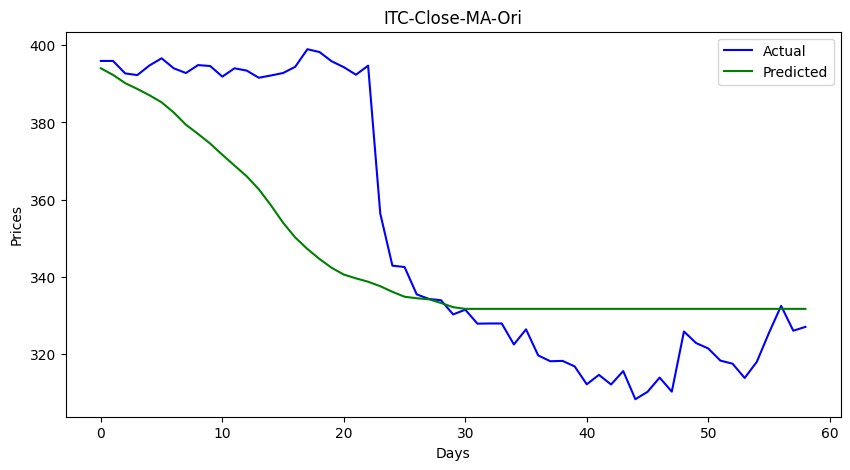

In [46]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","ITC-Close-MA-Ori","Days","Prices")

In [47]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 23.072755954938643
MAPE-Testset: 4.716195743179635


In [48]:
forecast=model_fit.predict(len(data1), len(data1)+1000)

In [49]:
forecast

array([0.53836638, 0.53836638, 0.53836638, ..., 0.53836638, 0.53836638,
       0.53836638], shape=(1001,))

In [50]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [51]:
forecast_stock_price_test_oriF

,Closefore
0,331.66773
1,331.66773
2,331.66773
3,331.66773
4,331.66773
...,...
996,331.66773
997,331.66773
998,331.66773
999,331.66773


In [52]:
forecast_stock_price_test_oriF.to_csv("CloseMA1.csv",index=False)

In [54]:
# # ===============================
# # 1️⃣ Import Libraries
# # ===============================
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import yfinance as yf

# from statsmodels.tsa.arima.model import ARIMA
# from statsmodels.tsa.stattools import adfuller
# from sklearn.metrics import mean_squared_error, r2_score


# # ===============================
# # 2️⃣ Download Stock Data
# # ===============================
# data = yf.download("ITC.NS", start="2021-01-01", end="2026-02-22")

# # Use Close price
# series = data["Close"].dropna()

# # ===============================
# # 3️⃣ Train Test Split (80/20)
# # ===============================
# train_size = int(len(series) * 0.8)
# X_train = series[:train_size]
# y_test = series[train_size:]

# print("Train size:", len(X_train))
# print("Test size:", len(y_test))


# # ===============================
# # 4️⃣ Stationarity Check (ADF Test)
# # ===============================
# result = adfuller(X_train)
# print("\nADF p-value:", result[1])

# if result[1] > 0.05:
#     print("Data is NOT stationary → differencing recommended")
# else:
#     print("Data is stationary")


# # ===============================
# # 5️⃣ Best Model (From Your Result)
# # Order = (1,0,0), Trend = 't'
# # ===============================
# order = (1, 0, 0)
# trend = "t"

# model = ARIMA(X_train, order=order, trend=trend)
# model_fit = model.fit()

# print("\nModel Summary:")
# print(model_fit.summary())


# # ===============================
# # 6️⃣ Predict Test Period
# # ===============================
# y_pred = model_fit.predict(
#     start=len(X_train),
#     end=len(X_train) + len(y_test) - 1
# )

# # ===============================
# # 7️⃣ Evaluation Metrics
# # ===============================
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# r2 = r2_score(y_test, y_pred)

# print("\nEvaluation Metrics")
# print("RMSE:", rmse)
# print("R2:", r2)


# # ===============================
# # 8️⃣ Plot Actual vs Predicted
# # ===============================
# plt.figure(figsize=(12,6))
# plt.plot(y_test.index, y_test, label="Actual")
# plt.plot(y_test.index, y_pred, label="Predicted")
# plt.legend()
# plt.title("Actual vs Predicted")
# plt.show()


# # ===============================
# # 9️⃣ Forecast Next 1000 Days
# # ===============================
# future_steps = 1000
# future_forecast = model_fit.forecast(steps=future_steps)

# print("\nFuture Forecast (First 5 values)")
# print(future_forecast.head())


# # ===============================
# # 🔟 Plot Future Forecast
# # ===============================
# plt.figure(figsize=(12,6))
# plt.plot(series.index, series, label="Historical")
# plt.plot(
#     pd.date_range(series.index[-1], periods=future_steps+1, freq='B')[1:],
#     future_forecast,
#     label="Future Forecast"
# )
# plt.legend()
# plt.title("Future 1000-Day Forecast")
# plt.show()